## Imports

In [20]:
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch_geometric.data import Data
from scipy.spatial import Delaunay

import networkx as nx
from torch_geometric.utils import to_networkx
import matplotlib.patches as mpatches

## GRAPHS FROM SYNTHETIC DATA

In [3]:
synthetic_1 = np.load('../data/preprocessing/normalized/normalized_local_norotation_close.npy')
synthetic_2 = np.load('../data/preprocessing/normalized/normalized_local_norotation_far.npy')
original = np.load('../data/preprocessing/normalized/normalized_local_norotation_original.npy')

In [4]:
def point_to_polyline_distance_vectorized(points, polyline):

    A = polyline[:-1]        # (M-1, 2)
    B = polyline[1:]         # (M-1, 2)
    AB = B - A               # (M-1, 2)
    AB_norm_sq = np.sum(AB ** 2, axis=1)  # (M-1,)

    # Expand dims for broadcasting
    P = points[:, None, :]   # (N,1,2)
    A = A[None, :, :]        # (1,M-1,2)
    AB = AB[None, :, :]      # (1,M-1,2)

    AP = P - A                      # (N,M-1,2)
    t = np.sum(AP * AB, axis=2) / (AB_norm_sq + 1e-12)  # (N, M-1)
    t = np.clip(t, 0.0, 1.0)

    proj = A + t[..., None] * AB    # (N,M-1,2)
    dist = np.linalg.norm(P - proj, axis=2)  # (N, M-1)

    return np.min(dist, axis=1)  # (N,)

In [5]:
def perpendicular_distance(points, polyline):

    # Segment directions
    v = polyline[1:] - polyline[:-1]           # (N-1,2)
    v = np.vstack([v, v[-1]])                  # pad last

    # Normal vectors (rotate by 90°)
    normals = np.stack([-v[:,1], v[:,0]], axis=1)
    normals /= (np.linalg.norm(normals, axis=1, keepdims=True) + 1e-12)

    # Vector from polyline to points
    diff = points - polyline                   # (N,2)

    # Signed perpendicular distance
    dist = np.sum(diff * normals, axis=1)
    return dist


In [6]:
def compute_orientation_angles(coords):
    
    dx = np.diff(coords[:, 0], append=coords[-1, 0])
    dy = np.diff(coords[:, 1], append=coords[-1, 1])
    angles = np.arctan2(dy, dx)
    angles = (angles + np.pi) / (2 * np.pi)  # normalize 0–1

    return angles.reshape(-1, 1)

In [15]:
def compute_orientation_features(coords, return_curvature=False):

    # Forward differences
    deltas = np.diff(coords, axis=0)

    # Repeat last direction to keep same length
    deltas = np.vstack([deltas, deltas[-1]])

    # Normalize direction vectors
    norms = np.linalg.norm(deltas, axis=1, keepdims=True) + 1e-12
    tangents = deltas / norms

    # Angle (for curvature computation only)
    angles = np.arctan2(tangents[:, 1], tangents[:, 0])

    # Orientation features (recommended)
    orient = np.stack([np.cos(angles), np.sin(angles)], axis=1)

    if not return_curvature:
        return orient

    # Curvature = change in angle (wrapped)
    dtheta = np.diff(angles, prepend=angles[0])
    dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi

    curvature = dtheta.reshape(-1, 1)

    return orient, curvature


In [18]:
def make_graphs(original, synthetic_1, synthetic_2, graph_type):
    
    num_seqs = original.shape[0]
    graphs = []

    for seq_idx in range(num_seqs):
        seq_len = original.shape[1]   # auto-detect length
         
        # Extract polylines
        orig = original[seq_idx][:seq_len]         # (N,2)
        syn1 = synthetic_1[seq_idx][:seq_len]      # (N,2)
        syn2 = synthetic_2[seq_idx][:seq_len]      # (N,2)
         
        # Compute node features
        feats = []

        # ----- Original line features -----
        angles_o, curvature_o = compute_orientation_features(orig, return_curvature=True)
        dist_o = perpendicular_distance(orig, syn1).reshape(-1, 1)

        feats_o = np.hstack([
            np.zeros((seq_len, 1)),      # line_id = 0
            orig,                        # x,y
            angles_o,                    # orientation
            curvature_o,                 # curvature 
            dist_o                       # dist to synthetic_1
        ])
        feats.append(feats_o)

        # ----- Synthetic_1 line features -----
        angles_s1, curvature_s1 = compute_orientation_features(syn1, return_curvature=True)
        dist_s1 = perpendicular_distance(syn1, orig).reshape(-1, 1)

        feats_s1 = np.hstack([
            np.ones((seq_len, 1)),       # line_id = 1
            syn1,
            angles_s1,
            curvature_s1,
            dist_s1
        ])
        feats.append(feats_s1)

        # Stack node features
        x = np.vstack(feats)  # (2*N, feature_dim)
         
        # Build edges
        edge_src = []
        edge_dst = []

        # Sequential edges in original line
        idx_offset_o = 0
        for i in range(seq_len - 1):
            edge_src += [idx_offset_o + i, idx_offset_o + i + 1]
            edge_dst += [idx_offset_o + i + 1, idx_offset_o + i]

       # Sequential edges in synthetic_1 line
        idx_offset_s1 = seq_len
        for i in range(seq_len - 1):
            edge_src += [idx_offset_s1 + i, idx_offset_s1 + i + 1]
            edge_dst += [idx_offset_s1 + i + 1, idx_offset_s1 + i]
        
        # Cross Edges original[i] <-> synthetic_1[i]
        if graph_type in ('sequential'):
            for i in range(seq_len):
                edge_src += [i, idx_offset_s1 + i]
                edge_dst += [idx_offset_s1 + i, i]
        
        # Delaunay edges
        if graph_type in ('delaunay', 'hybrid'):
            all_points = np.vstack([orig, syn1])  # shape: (2N,2)
            tri = Delaunay(all_points)
            triangles = tri.simplices  # (T,3)

            tri_edges = set()
            for a, b, c in triangles:
                tri_edges.add(tuple(sorted((a, b))))
                tri_edges.add(tuple(sorted((b, c))))
                tri_edges.add(tuple(sorted((c, a))))

            for u, v in tri_edges:
                edge_src += [u, v]
                edge_dst += [v, u]

        # Final edge index
        #edge_index = np.vstack([edge_src, edge_dst]).astype(np.int64)
        edges = set(zip(edge_src, edge_dst))
        edge_src, edge_dst = zip(*edges)
        edge_index = np.vstack([edge_src, edge_dst]).astype(np.int64)
         
        # Target: shift of synthetic_1 → synthetic_2
        shift = syn2 - syn1         # (N,2)

        y = np.zeros((2 * seq_len, 2), dtype=np.float32)
        y[idx_offset_s1:idx_offset_s1 + seq_len] = shift  # only syn1 nodes
         
        # Convert to PyTorch
        data = Data(
            x=torch.tensor(x, dtype=torch.float),
            edge_index=torch.tensor(edge_index, dtype=torch.long),
            y=torch.tensor(y, dtype=torch.float)
        )
        graphs.append(data)

    return graphs


In [19]:
graphs_seq = make_graphs(original, synthetic_1, synthetic_2, 'sequential')

In [21]:
graphs_delaunay = make_graphs(original, synthetic_1, synthetic_2, 'delaunay')

### Save Results

In [31]:
torch.save(graphs_seq, f'../data/final_dataset/graph/graphs_sequential_norotation_local_new.pt')
torch.save(graphs_delaunay, f'../data/final_dataset/graph/graphs_delaunay_norotation_local_new.pt')
#graphs_seq = torch.load('../data/final_dataset/graph/graphs_sequential_norotation_local.pt', weights_only=False)
#graphs_delaunay = torch.load('../data/final_dataset/graph/graphs_delaunay_norotation_local.pt', weights_only=False)

### Ploting Graphs

In [29]:
def plot_graph(data, index, saving_img=False):
    # Convert PyG Data -> NetworkX
    G = to_networkx(data, to_undirected=True)
    pos = {i: (float(data.x[i][1]), float(data.x[i][2])) for i in range(data.num_nodes)}

    # Node colors by line_id
    color_map = ["#143642", "#EC9A29"]
    colors = [color_map[int(data.x[i][0].item())] for i in range(data.num_nodes)]

    plt.figure(figsize=(8, 7))
    plt.title(f'Constructed Graph with Sequential Lines - Line {index}')
    plt.xlabel('X')
    plt.ylabel('Y')

    # Draw graph
    nx.draw(
        G, pos,
        node_size=5,
        node_color=colors,
        edge_color="#B3B5B6A6",
        alpha=0.8
    )

    # ---- Legend ----
    legend_patches = [
        mpatches.Patch(color=color_map[0], label='Line A'),
        mpatches.Patch(color=color_map[1], label='Line B')
    ]
    plt.legend(handles=legend_patches, title="Line IDs")
    
    if saving_img:
        save_path = f'../data/figures/graph_sequential.png'
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


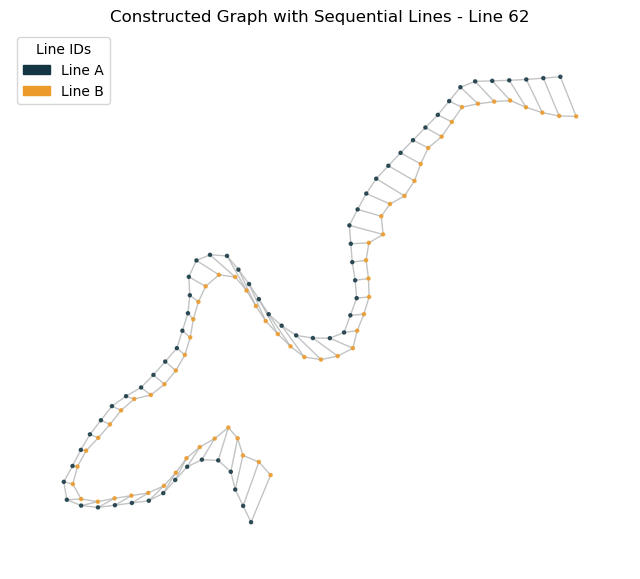

In [30]:
graph = graphs_seq

for i in range(62,63):
    plot_graph(graph[i], i)